# *1 — Import Libraries*

In [18]:
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## 2 — Dataset path


In [19]:
DATASET_DIR = Path("../dataset/RDD_SPLIT")

TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"
TEST_DIR = DATASET_DIR / "test"

print("Dataset:", DATASET_DIR)
print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

Dataset: ..\dataset\RDD_SPLIT
Train: ..\dataset\RDD_SPLIT\train
Validation: ..\dataset\RDD_SPLIT\val
Test: ..\dataset\RDD_SPLIT\test


## 3 —Find Images and Labels

In [20]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}


def get_files(folder):

    images = []
    labels = []

    if folder.exists():

        for file in folder.rglob("*"):

            if file.is_file():

                if file.suffix.lower() in IMAGE_EXTENSIONS:
                    images.append(file)

                elif file.suffix.lower() == ".txt":
                    labels.append(file)

    return images, labels


train_images, train_labels = get_files(TRAIN_DIR)
val_images, val_labels = get_files(VAL_DIR)
test_images, test_labels = get_files(TEST_DIR)


print("Train Images:", len(train_images))
print("Train Labels:", len(train_labels))

print("Validation Images:", len(val_images))
print("Validation Labels:", len(val_labels))

print("Test Images:", len(test_images))
print("Test Labels:", len(test_labels))

Train Images: 26869
Train Labels: 26869
Validation Images: 5758
Validation Labels: 5758
Test Images: 5758
Test Labels: 5758


### 4 — Dataset Summary Table

In [21]:
dataset_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Images": [
        len(train_images),
        len(val_images),
        len(test_images)
    ],
    "Annotations": [
        len(train_labels),
        len(val_labels),
        len(test_labels)
    ]
})

dataset_summary

,Split,Images,Annotations
0,Train,26869,26869
1,Validation,5758,5758
2,Test,5758,5758


## 5 — Dataset Split Visualization

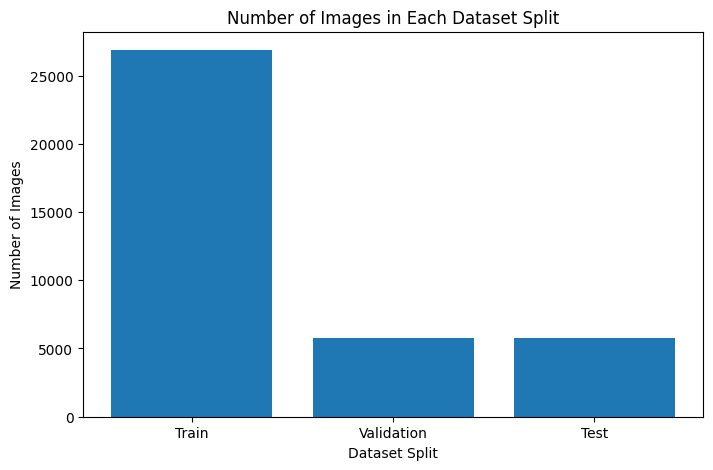

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    dataset_summary["Split"],
    dataset_summary["Images"]
)

plt.title("Number of Images in Each Dataset Split")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")

plt.show()

### 6— Overall Class Distribution

In [23]:
class_names = {
    0: "D00",
    1: "D10",
    2: "D20",
    3: "D40",
    4: "D43"
}


def get_class_distribution(label_files):

    counter = Counter()

    for label_file in label_files:

        try:

            with open(label_file, "r") as f:

                for line in f:

                    parts = line.strip().split()

                    if len(parts) >= 5:

                        class_id = int(parts[0])

                        counter[class_id] += 1

        except Exception:
            pass

    return counter


train_class_counts = get_class_distribution(train_labels)

print("Training Class Distribution:")

for class_id in sorted(class_names):

    print(
        class_names[class_id],
        ":",
        train_class_counts.get(class_id, 0)
    )

Training Class Distribution:
D00 : 18201
D10 : 8386
D20 : 7527
D40 : 7554
D43 : 4628


### 7 — Class Distribution Table

In [24]:
class_distribution = pd.DataFrame({
    "Class ID": list(class_names.keys()),
    "Damage Type": list(class_names.values()),
    "Number of Annotations": [
        train_class_counts.get(class_id, 0)
        for class_id in class_names.keys()
    ]
})

class_distribution

,Class ID,Damage Type,Number of Annotations
0,0,D00,18201
1,1,D10,8386
2,2,D20,7527
3,3,D40,7554
4,4,D43,4628


## 8 — Class Distribution Graph

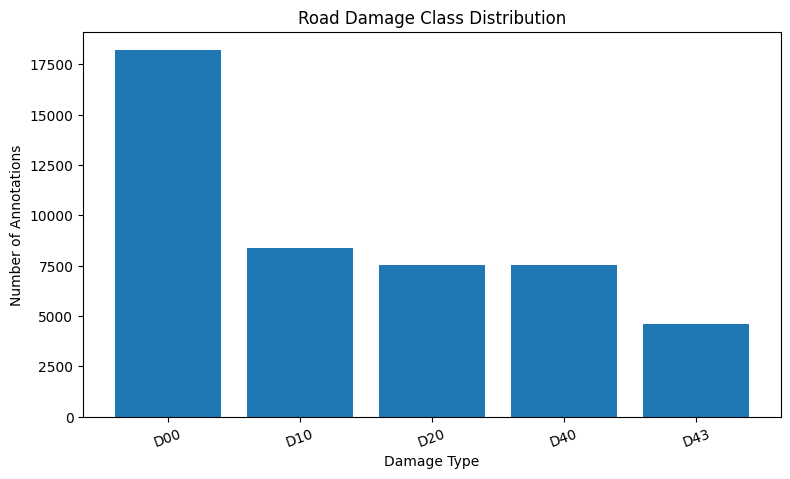

In [25]:
plt.figure(figsize=(9, 5))

plt.bar(
    class_distribution["Damage Type"],
    class_distribution["Number of Annotations"]
)

plt.title("Road Damage Class Distribution")
plt.xlabel("Damage Type")
plt.ylabel("Number of Annotations")

plt.xticks(rotation=20)

plt.show()

## 9 — Class Percentages

In [26]:
total_annotations = class_distribution[
    "Number of Annotations"
].sum()

class_distribution["Percentage"] = (
    class_distribution["Number of Annotations"]
    / total_annotations
) * 100

class_distribution

,Class ID,Damage Type,Number of Annotations,Percentage
0,0,D00,18201,39.314412
1,1,D10,8386,18.113876
2,2,D20,7527,16.258424
3,3,D40,7554,16.316744
4,4,D43,4628,9.996544


### 10 — Sample Road Images

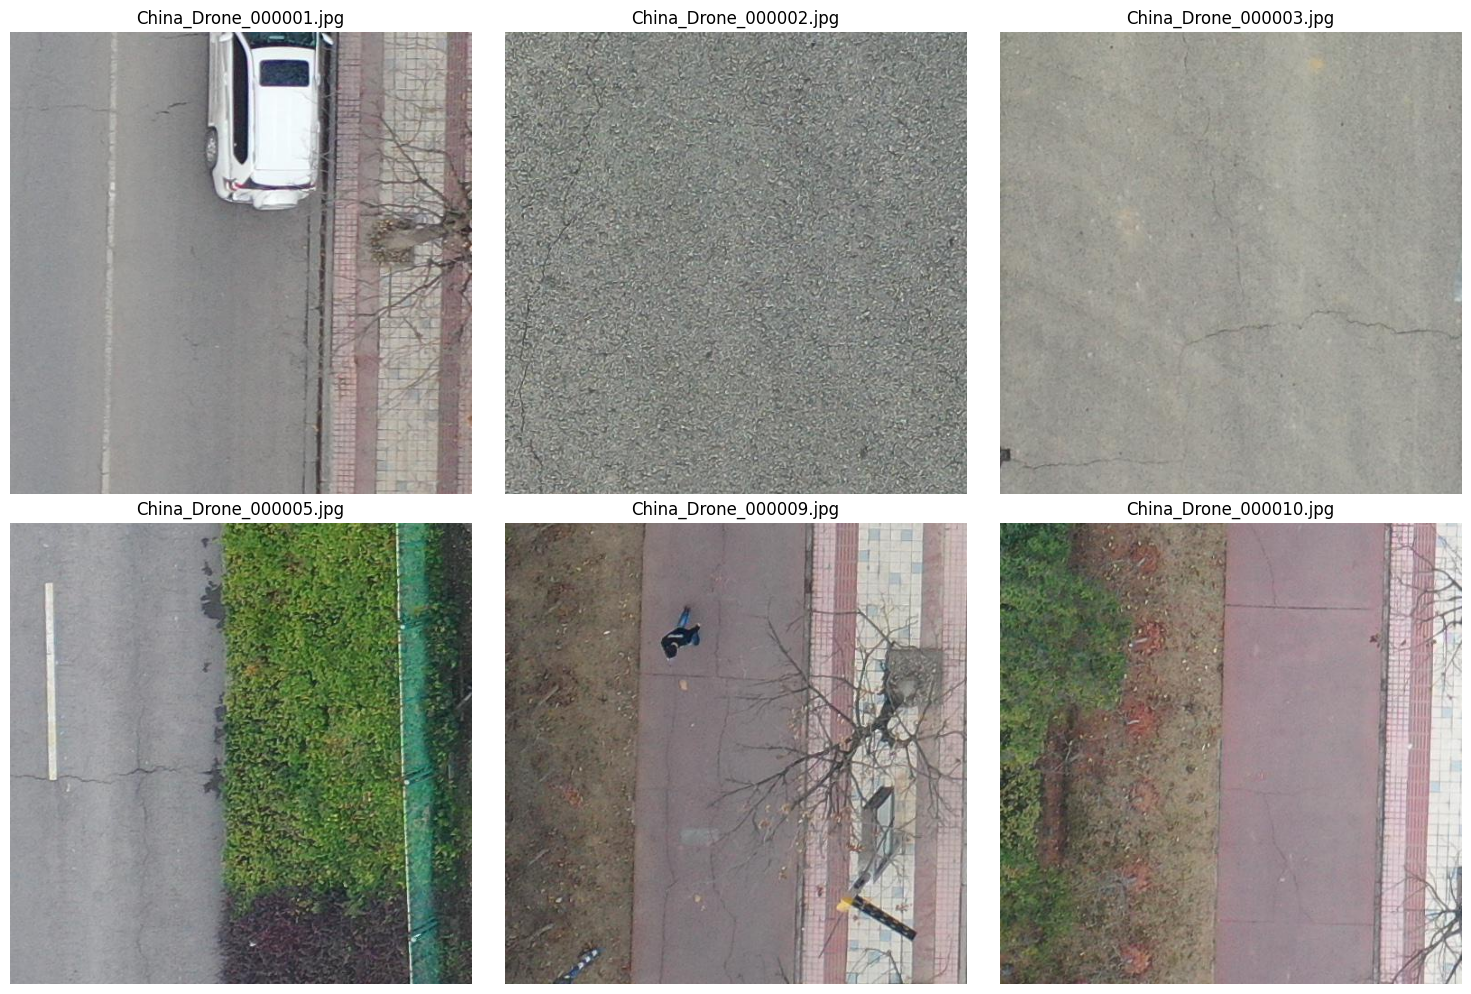

In [27]:
sample_images = train_images[:6]

plt.figure(figsize=(15, 10))

for i, image_path in enumerate(sample_images):

    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(image_path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

### 11 — Bounding Box Visualization

In [28]:
def draw_yolo_boxes(image_path, label_path):

    image = cv2.imread(str(image_path))

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    height, width = image.shape[:2]

    if label_path.exists():

        with open(label_path, "r") as f:

            for line in f:

                parts = line.strip().split()

                if len(parts) < 5:
                    continue

                class_id = int(parts[0])

                x_center = float(parts[1])
                y_center = float(parts[2])
                box_width = float(parts[3])
                box_height = float(parts[4])

                x1 = int(
                    (x_center - box_width / 2) * width
                )

                y1 = int(
                    (y_center - box_height / 2) * height
                )

                x2 = int(
                    (x_center + box_width / 2) * width
                )

                y2 = int(
                    (y_center + box_height / 2) * height
                )

                cv2.rectangle(
                    image,
                    (x1, y1),
                    (x2, y2),
                    (255, 0, 0),
                    2
                )

                cv2.putText(
                    image,
                    class_names.get(class_id, str(class_id)),
                    (x1, max(y1 - 10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (255, 0, 0),
                    2
                )

    return image

### 12 — Display Bounding Boxes

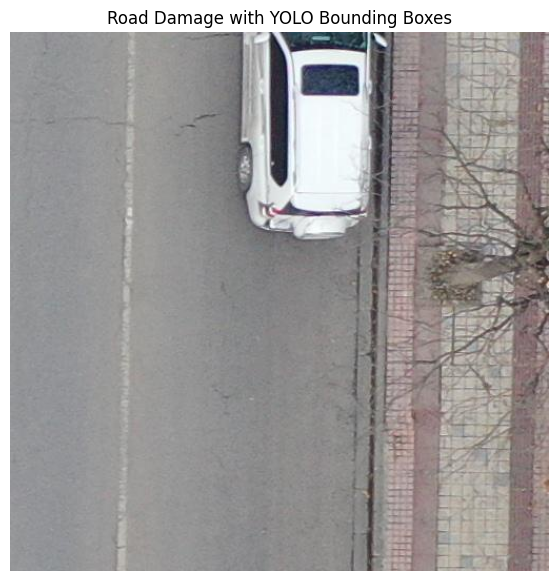

In [29]:
if len(train_images) > 0:

    image_path = train_images[0]
    label_path = image_path.with_suffix(".txt")

    result_image = draw_yolo_boxes(
        image_path,
        label_path
    )

    plt.figure(figsize=(12, 7))
    plt.imshow(result_image)
    plt.title("Road Damage with YOLO Bounding Boxes")
    plt.axis("off")
    plt.show()

## 13 — Multiple Annotated Images

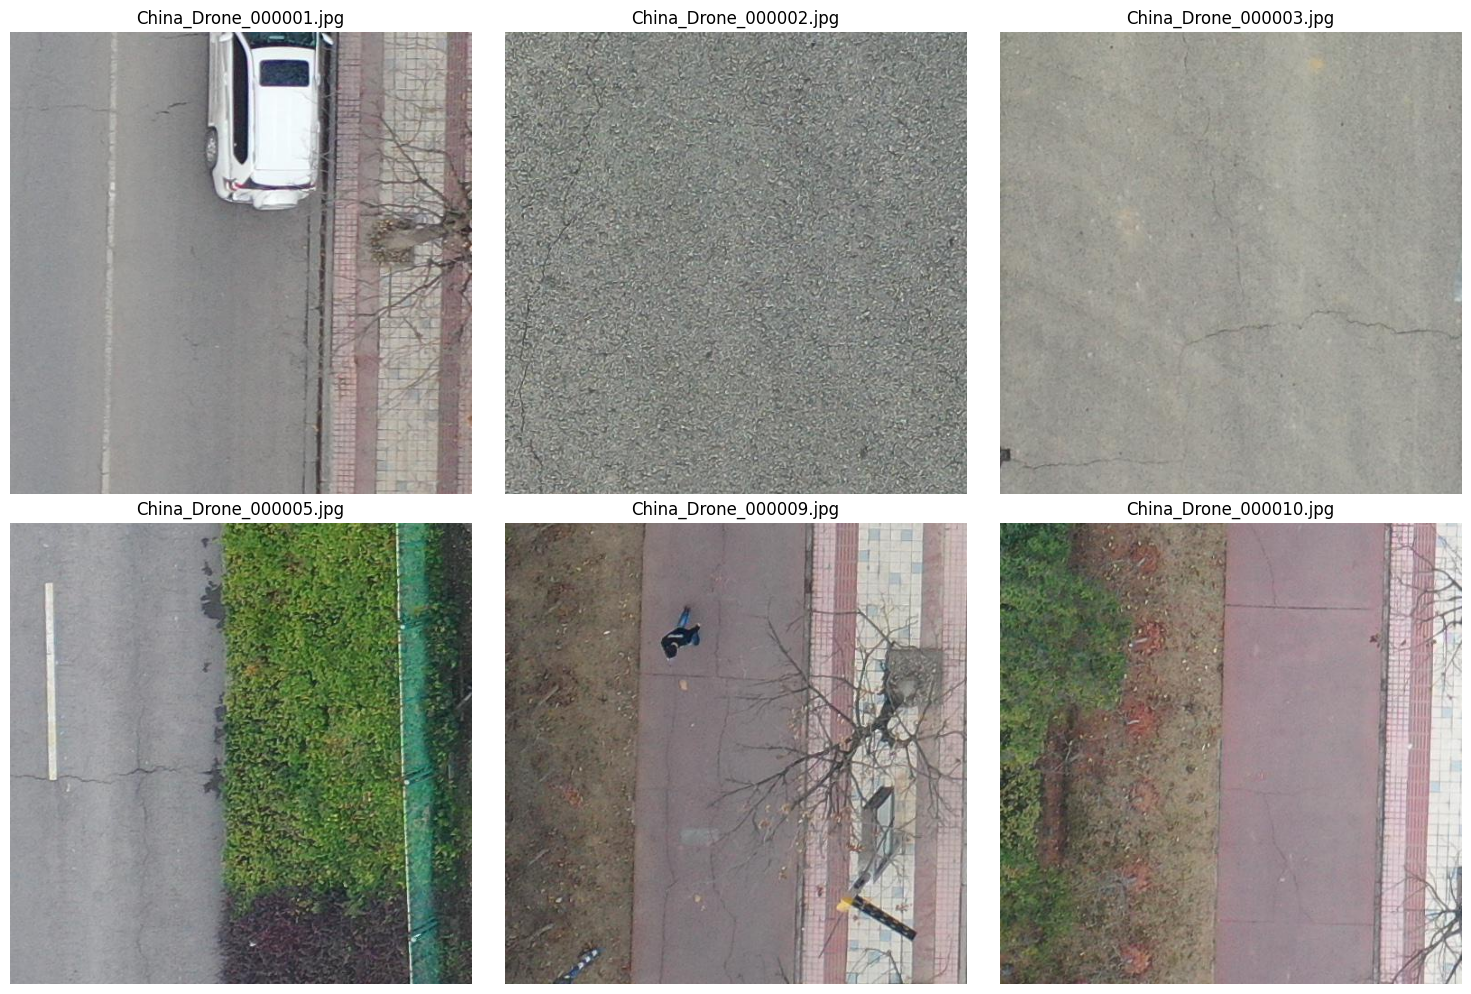

In [30]:
sample_images = train_images[:6]

plt.figure(figsize=(15, 10))

for i, image_path in enumerate(sample_images):

    label_path = image_path.with_suffix(".txt")

    result_image = draw_yolo_boxes(
        image_path,
        label_path
    )

    plt.subplot(2, 3, i + 1)

    plt.imshow(result_image)

    plt.title(image_path.name)

    plt.axis("off")


plt.tight_layout()
plt.show()

### 14 — Image Dimension Analysis

In [31]:
image_dimensions = []

for image_path in train_images:

    image = cv2.imread(str(image_path))

    if image is not None:

        height, width = image.shape[:2]

        image_dimensions.append(
            (width, height)
        )


dimension_df = pd.DataFrame(
    image_dimensions,
    columns=["Width", "Height"]
)

dimension_df.describe()

,Width,Height
count,26869.000000,26869.000000
mean,1312.410287,926.690684
std,1324.773208,581.119420
min,512.000000,512.000000
25%,600.000000,600.000000
50%,640.000000,640.000000
75%,720.000000,720.000000
max,4040.000000,2044.000000


## 15 — Width/Height Distribution

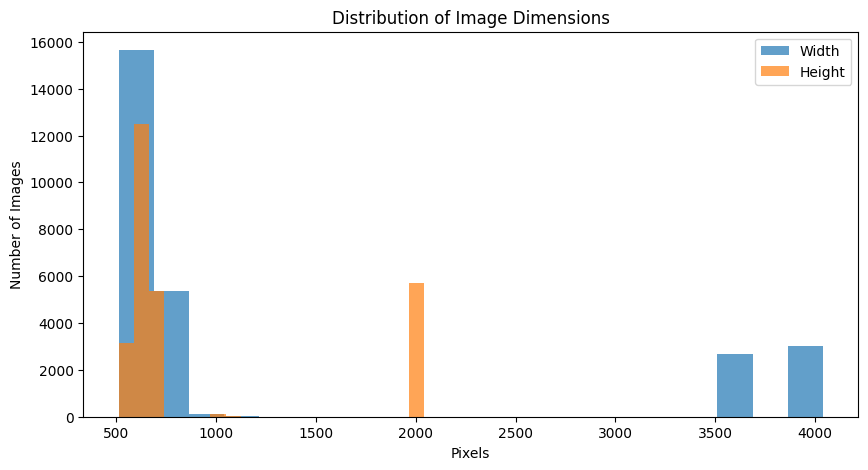

In [32]:
plt.figure(figsize=(10, 5))

plt.hist(
    dimension_df["Width"],
    bins=20,
    alpha=0.7,
    label="Width"
)

plt.hist(
    dimension_df["Height"],
    bins=20,
    alpha=0.7,
    label="Height"
)

plt.title("Distribution of Image Dimensions")
plt.xlabel("Pixels")
plt.ylabel("Number of Images")

plt.legend()

plt.show()

## 16 — Empty Annotation Check

In [33]:
empty_labels = []

for label_file in train_labels:

    if label_file.stat().st_size == 0:

        empty_labels.append(label_file)


print("Empty annotation files:", len(empty_labels))

Empty annotation files: 8097


### 17 — Missing Labels Check

In [ ]:
missing_labels = []

for image_path in train_images:

    label_path = image_path.with_suffix(".txt")

    if not label_path.exists():

        missing_labels.append(image_path)


print("Images without labels:", len(missing_labels))

Images without labels: 26869


: 

## 📊 EDA Findings

The exploratory data analysis provided an overview of the road damage dataset.

### Dataset Analysis

* The dataset was divided into training, validation, and testing sets.
* The number of images and annotation files in each dataset split was analyzed.
* Five road damage classes were identified: D00, D10, D20, D40, and D43.

### Class Distribution

* The distribution of road damage classes was analyzed using a table and bar chart.
* The class percentages were calculated to identify differences in the number of annotations among damage categories.

### Image Analysis

* Sample road images from the training dataset were visualized.
* Image dimensions were analyzed to understand the variation in image sizes.
* YOLO bounding-box annotations were visualized on sample road images.

### Data Quality Checks

* Empty annotation files were checked.
* Images without corresponding annotation files were checked.

### Conclusion

The exploratory analysis provides an understanding of the dataset structure, road damage classes, image characteristics, and annotation quality. The dataset is ready for the next stage of the project: model training and evaluation.
